In [4]:
import pyodbc, pandas
from warnings import filterwarnings

filterwarnings("ignore", category=UserWarning, message='.*pandas only supports SQLAlchemy connectable.*')

pandas.set_option('display.width', 175)

cnxn = pyodbc.connect("DSN=Apache Arrow Flight SQL Demo", autocommit=True)

print('Connected.')

Connected.


In [5]:
sql = '''select * from Samples."samples.dremio.com"."NYC-taxi-trips" LIMIT 10'''

data = pandas.read_sql(sql,cnxn)

print(data)

      pickup_datetime  passenger_count  trip_distance_mi  fare_amount  tip_amount  total_amount
0 2013-05-27 19:15:00                1              1.26          7.5        0.00          8.00
1 2013-05-31 16:40:00                1              0.73          5.0        1.20          7.70
2 2013-05-27 19:03:00                2              9.23         27.5        5.00         38.33
3 2013-05-31 16:24:00                1              2.27         12.0        0.00         13.50
4 2013-05-27 19:17:00                1              0.71          5.0        0.00          5.50
5 2013-05-27 19:11:00                1              2.52         10.5        3.15         14.15
6 2013-05-31 16:41:00                5              1.01          6.0        1.10          8.60
7 2013-05-31 16:37:00                1              1.25          8.5        0.00         10.00
8 2013-05-31 16:39:00                1              2.04         10.0        1.50         13.00
9 2013-05-27 19:02:00                1  

   fare_year      sum_fare
0       2014  2.518407e+09
1       2013  2.561193e+09


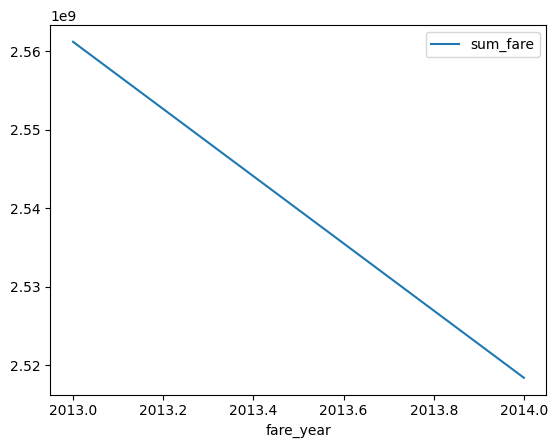

In [6]:
import matplotlib.pyplot as plt
plt.rcdefaults()

sql = '''select YEAR(pickup_datetime) as fare_year, SUM(total_amount) as sum_fare from Samples."samples.dremio.com"."NYC-taxi-trips" group by 1 LIMIT 1000'''

data = pandas.read_sql(sql, cnxn)
print(data)
data.plot(x='fare_year', y='sum_fare')
plt.show()